In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\vic\Downloads\student_failure_dataset.csv")

In [3]:
df.head()

,total_workload,avg_grade,class_avg,failed_quizzes,homework_accuracy,assignment_completion_rate,class_attendance_rate,avg_test_quiz_scores,class_avg_test_quiz_scores,study_consistency,...,stress_level,confidence_level,anxiety_level,resilience,growth_mindset,age,class_level,socioeconomic_status,internet_access_barrier,student_failure_risk_pct
0,7,34.54,29.60,0.0,NaN,80.86,91.71,9.68,12.35,Inconsistent,...,High,Moderate,Mild,Developing,Moderate,13,Junior Secondary,Medium,Low,69.34
1,20,54.17,48.49,2.0,NaN,67.21,70.94,10.59,12.94,Moderate,...,Low,Moderate,High,Low,Low,19,Undergraduate,High,Low,84.66
2,15,35.18,38.88,NaN,76.10,96.39,78.53,16.58,18.03,Very High,...,Moderate,Moderate,Very High,Low,Low,23,Bachelors Degree,Low,High,78.58
3,11,54.01,53.94,1.0,NaN,98.01,86.56,14.88,16.46,Moderate,...,Moderate,High,High,Low,Fixed,28,Masters Degree,Low,Low,48.67
4,8,58.49,54.82,0.0,88.77,73.87,99.57,12.46,13.01,Inconsistent,...,High,Moderate,Mild,Good,Moderate,19,Higher National Diploma,Medium,Low,35.07


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   total_workload              5000 non-null   int64  
 1   avg_grade                   5000 non-null   float64
 2   class_avg                   5000 non-null   float64
 3   failed_quizzes              2565 non-null   float64
 4   homework_accuracy           2989 non-null   float64
 5   assignment_completion_rate  5000 non-null   float64
 6   class_attendance_rate       5000 non-null   float64
 7   avg_test_quiz_scores        5000 non-null   float64
 8   class_avg_test_quiz_scores  5000 non-null   float64
 9   study_consistency           5000 non-null   object 
 10  focus_quality               5000 non-null   object 
 11  self_regulation             5000 non-null   object 
 12  procrastination_level       5000 non-null   object 
 13  goal_setting_behavior       5000 

In [5]:
df.shape

(5000, 24)

In [6]:
df.isna().sum()

total_workload                   0
avg_grade                        0
class_avg                        0
failed_quizzes                2435
homework_accuracy             2011
assignment_completion_rate       0
class_attendance_rate            0
avg_test_quiz_scores             0
class_avg_test_quiz_scores       0
study_consistency                0
focus_quality                    0
self_regulation                  0
procrastination_level            0
goal_setting_behavior            0
stress_level                     0
confidence_level                 0
anxiety_level                    0
resilience                       0
growth_mindset                   0
age                              0
class_level                      0
socioeconomic_status             0
internet_access_barrier          0
student_failure_risk_pct         0
dtype: int64

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, Model

# Assuming your DataFrame is called df

categorical_cols = [
    'study_consistency', 'focus_quality', 'self_regulation', 'procrastination_level',
    'goal_setting_behavior', 'stress_level', 'confidence_level', 'anxiety_level',
    'resilience', 'growth_mindset', 'class_level', 'socioeconomic_status', 'internet_access_barrier'
]

numerical_cols = [
    'total_workload', 'avg_grade', 'class_avg', 'failed_quizzes', 'homework_accuracy',
    'assignment_completion_rate', 'class_attendance_rate', 'avg_test_quiz_scores',
    'class_avg_test_quiz_scores', 'age'
]

target_col = 'student_failure_risk_pct'

In [8]:
# Replace categorical NaNs with the token "Optional"
df[categorical_cols] = df[categorical_cols].fillna("Optional")

In [9]:
# Create a sentence-like representation for transformer input
categorical_texts = df[categorical_cols].astype(str).agg(" ".join, axis=1)

# Text vectorizer (tokenize categories)
text_vectorizer = layers.TextVectorization(
    output_mode="int",
    output_sequence_length=len(categorical_cols)
)
text_vectorizer.adapt(categorical_texts)
vocab_size = len(text_vectorizer.get_vocabulary())

In [10]:
# Fill numeric NaNs with 0 (or the column mean if you prefer)
df[numerical_cols] = df[numerical_cols].apply(
    lambda x: x.fillna(x.mean()) if x.dtype != "O" else x
)

In [11]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [12]:
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    categorical_texts, df[numerical_cols], df[target_col], test_size=0.2, random_state=42
)

X_train_seq = text_vectorizer(X_train_text)
X_test_seq = text_vectorizer(X_test_text)

In [13]:
def tab_transformer_block(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
    # Layer Norm
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    
    # Multi-head self-attention
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs  # residual connection
    
    # Feed-forward
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    
    return x + res

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class NumericMaskingLayer(layers.Layer):
    """Mask NaNs in numeric inputs."""
    def call(self, inputs):
        mask = tf.cast(tf.math.is_finite(inputs), tf.float32)
        masked = tf.where(tf.math.is_finite(inputs), inputs, tf.zeros_like(inputs))
        return masked, mask

In [15]:
# Categorical path
text_input = layers.Input(shape=(len(categorical_cols),), dtype=tf.int32, name="categorical_sequence")
x = layers.Embedding(input_dim=vocab_size, output_dim=64)(text_input)
x = tab_transformer_block(x)
x = tab_transformer_block(x)
x = layers.GlobalAveragePooling1D()(x)

# Numerical path
num_input = layers.Input(shape=(len(numerical_cols),), name="numerical_input")
masked_num, mask = NumericMaskingLayer()(num_input)
num_dense = layers.Dense(64, activation="relu")(masked_num)
num_dense = layers.Concatenate()([num_dense, mask])

# Combine paths
combined = layers.Concatenate()([x, num_dense])
combined = layers.Dense(128, activation="relu")(combined)
combined = layers.Dropout(0.3)(combined)
combined = layers.Dense(64, activation="relu")(combined)
output = layers.Dense(1, activation="linear")(combined)

# Compile
model = Model(inputs=[text_input, num_input], outputs=output)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ categorical_sequen… │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 13, 64)    │      2,432 │ categorical_sequ… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 13, 64)    │        128 │ embedding[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 13, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 13, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 13, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 13, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 13, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 13, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 13, 64)    │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 13, 64)    │          0 │ dense_1[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 13, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 13, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 13, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 13, 64)    │          0 │ dropout_4[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 13, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 13, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 13, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_input     │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 195,649 (764.25 KB)

 Trainable params: 195,649 (764.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    {"categorical_sequence": X_train_seq, "numerical_input": X_train_num},
    y_train,
    validation_data=(
        {"categorical_sequence": X_test_seq, "numerical_input": X_test_num},
        y_test
    ),
    epochs=50,  # you can increase further
    batch_size=64,
    verbose=1
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - loss: 980.0337 - mae: 25.7332 - val_loss: 685.3552 - val_mae: 21.8730
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 611.9355 - mae: 20.7973 - val_loss: 528.5192 - val_mae: 19.2341
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - loss: 529.7062 - mae: 19.1223 - val_loss: 509.1879 - val_mae: 18.6035
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 519.7393 - mae: 18.7218 - val_loss: 503.6146 - val_mae: 18.6142
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 500.4670 - mae: 18.4817 - val_loss: 493.1284 - val_mae: 18.4179
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 514.5870 - mae: 18.5361 - val_loss: 505.2644 - val_mae: 18.7035
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 504.0201 - mae: 18.3966 - val_loss: 500.5787 - val_mae: 18.7898
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 493.6171 - mae: 18.3108 - val_loss: 527.7562 - val_mae: 18.5758
Epoch 9/50
63

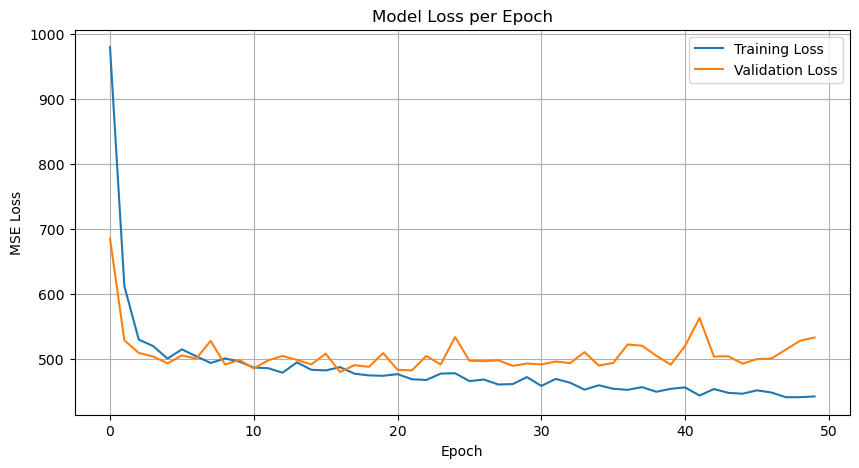

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

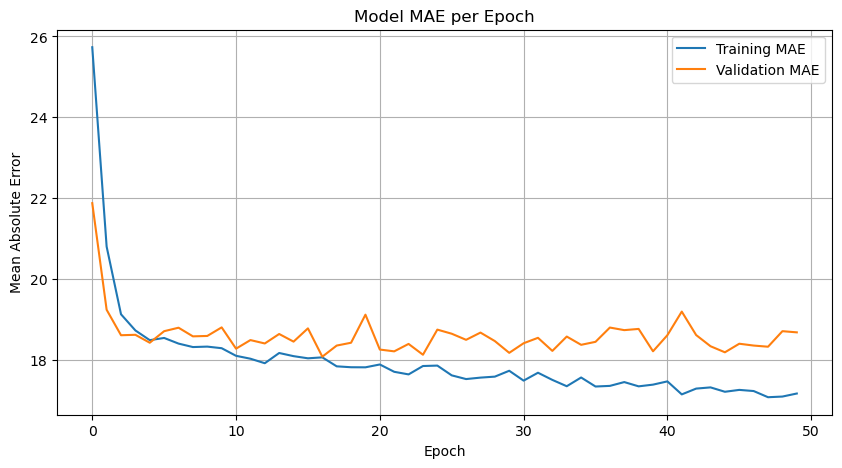

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\vic\AppData\Local\Temp\ipykernel_7560\1542826978.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['study_consistency'], y=df[target_col], palette='Set2')


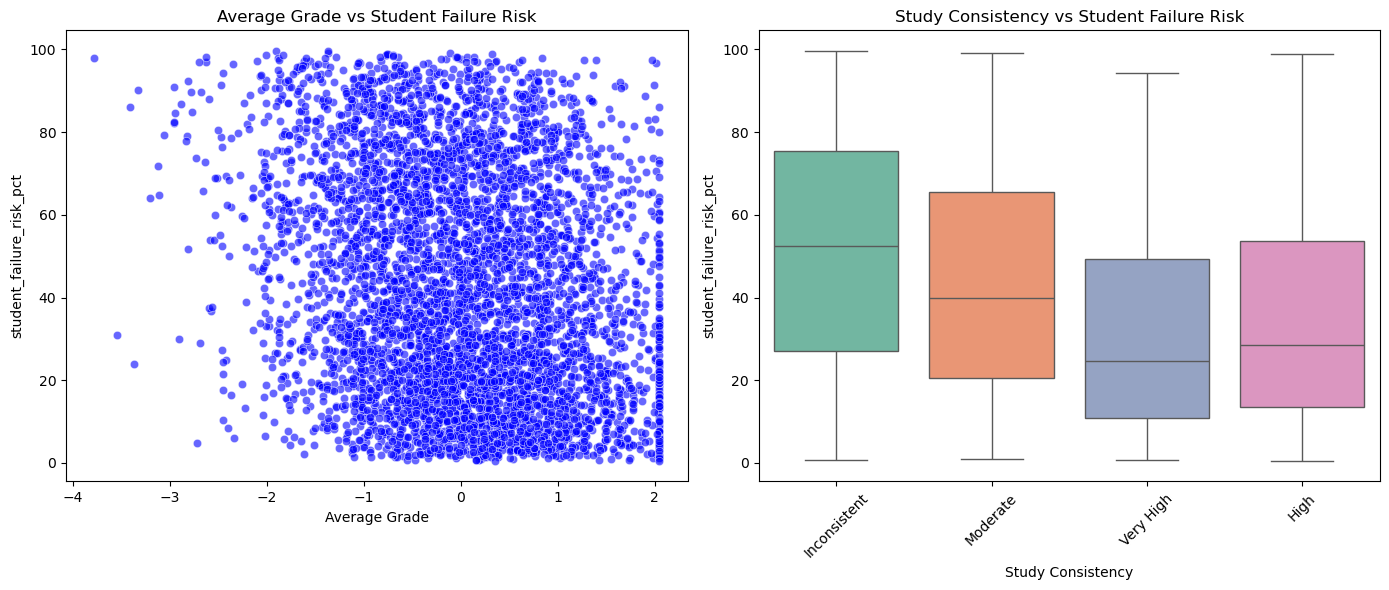

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

#Numerical Feature vs Target (example: avg_grade)
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['avg_grade'], y=df[target_col], color='blue', alpha=0.6)
plt.title('Average Grade vs Student Failure Risk')
plt.xlabel('Average Grade')
plt.ylabel(target_col)

#Categorical Feature vs Target (example: study_consistency)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['study_consistency'], y=df[target_col], palette='Set2')
plt.title('Study Consistency vs Student Failure Risk')
plt.xlabel('Study Consistency')
plt.ylabel(target_col)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


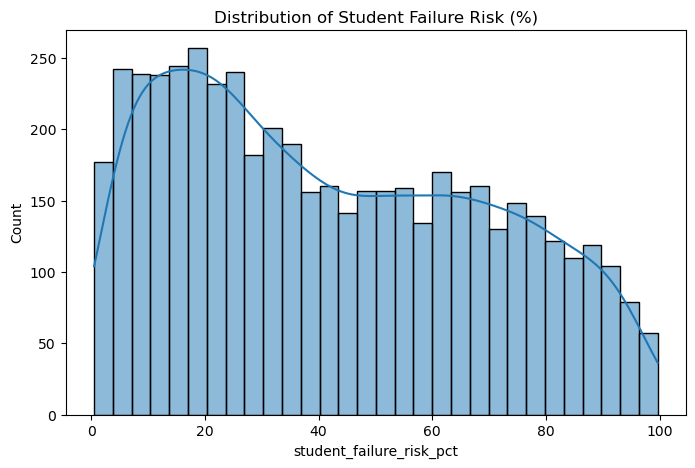

In [18]:
#Target Distribution
plt.figure(figsize=(8,5))
sns.histplot(df[target_col], bins=30, kde=True)
plt.title("Distribution of Student Failure Risk (%)")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.show()

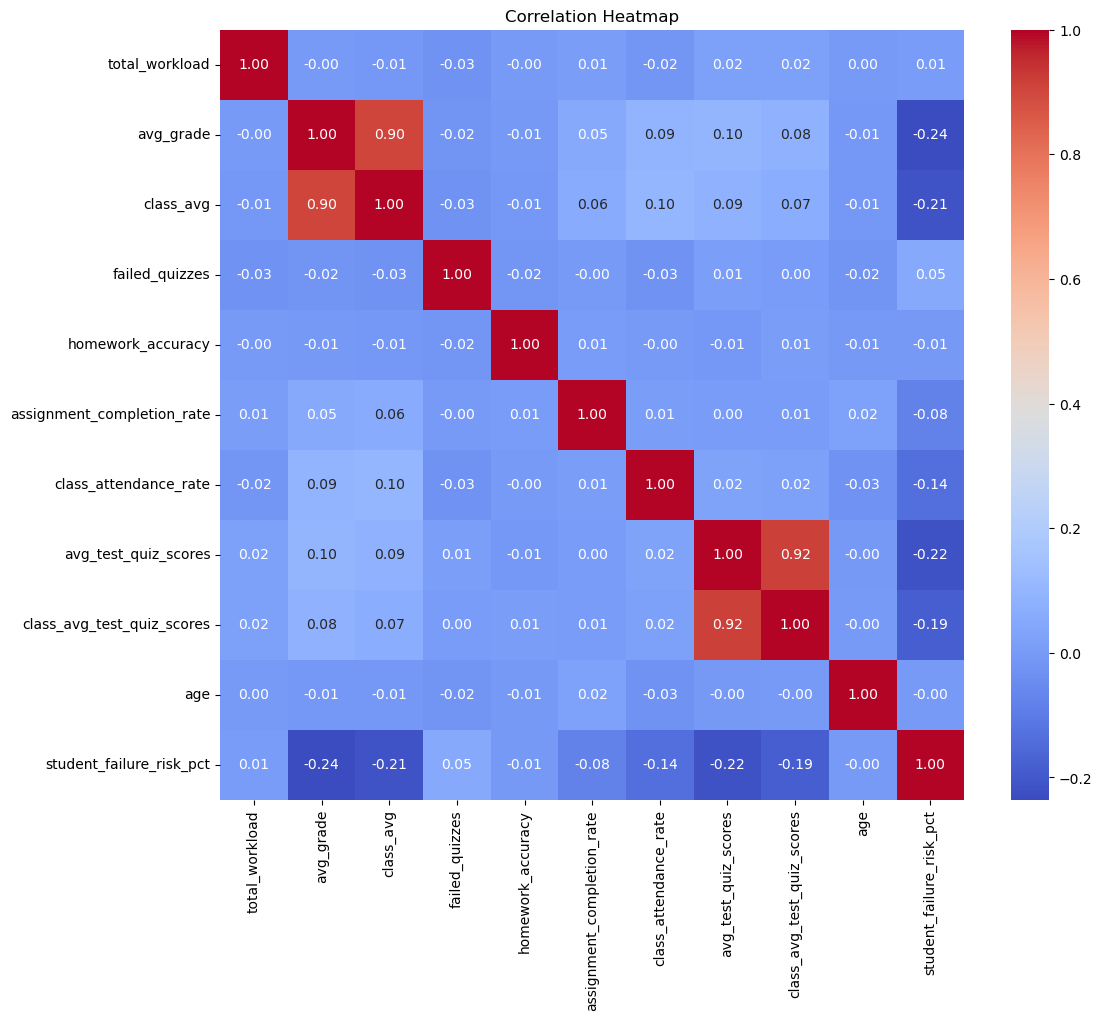

In [19]:
#Correlation Heatmap (numerical features)
plt.figure(figsize=(12,10))
corr = df[numerical_cols + [target_col]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

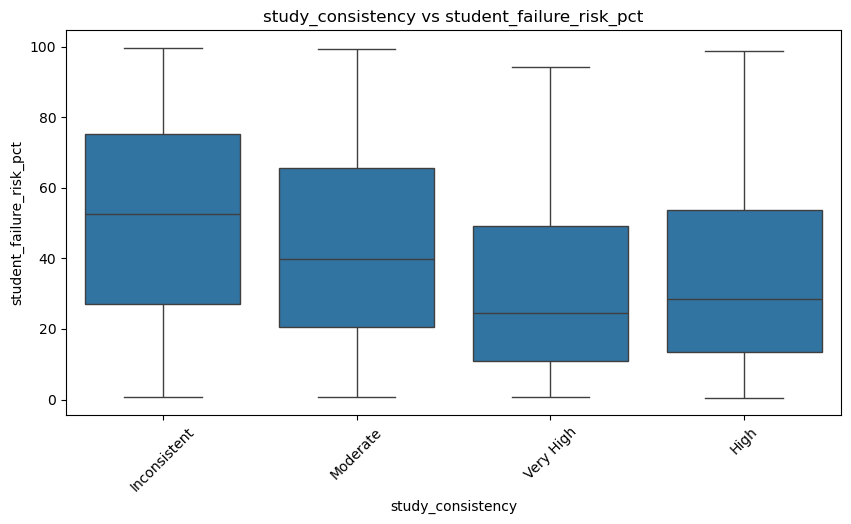

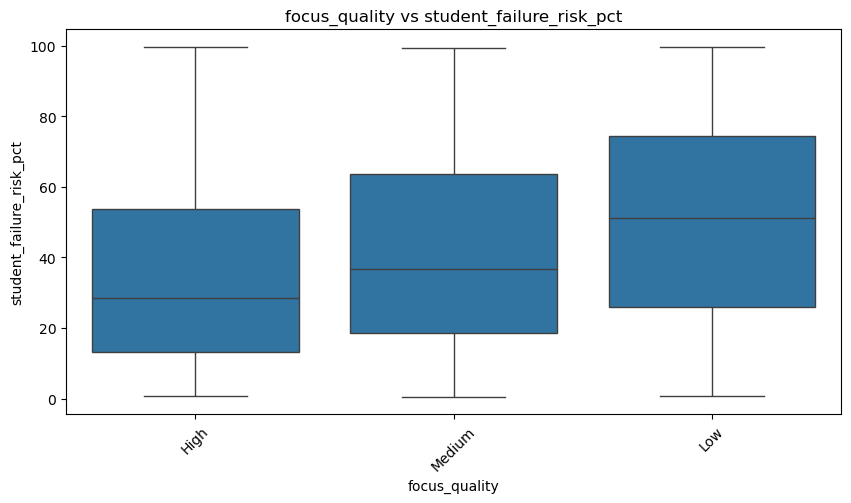

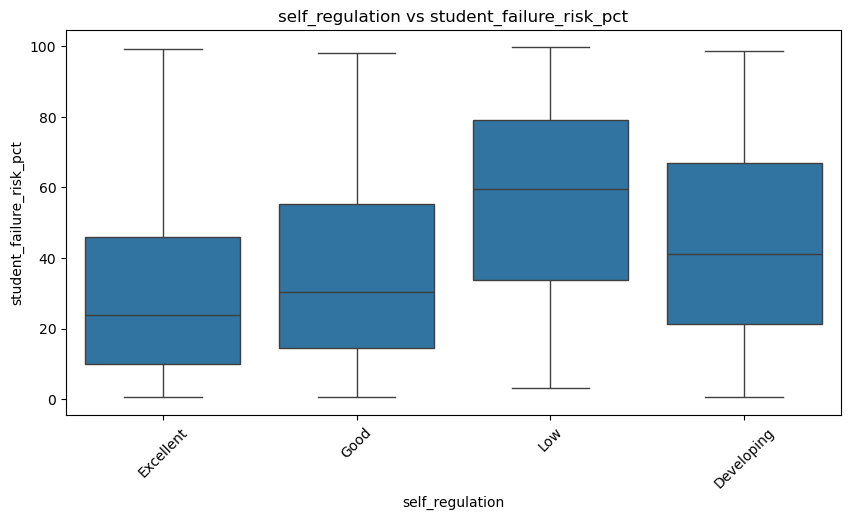

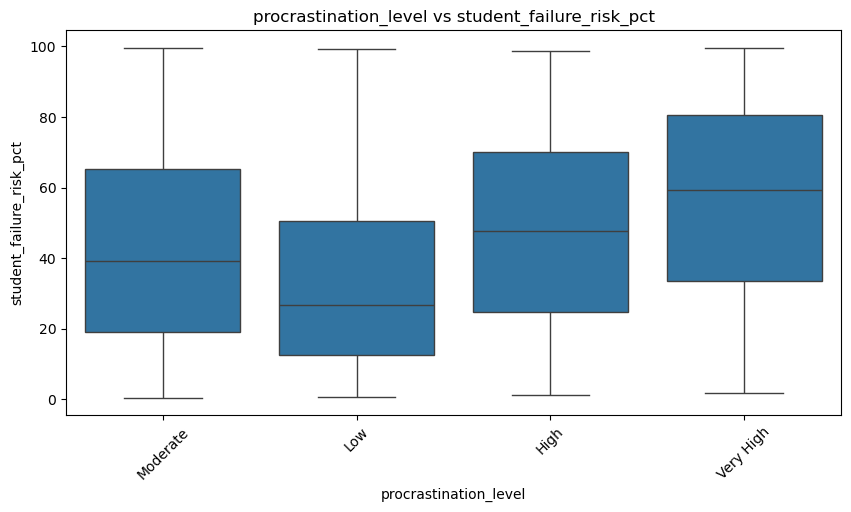

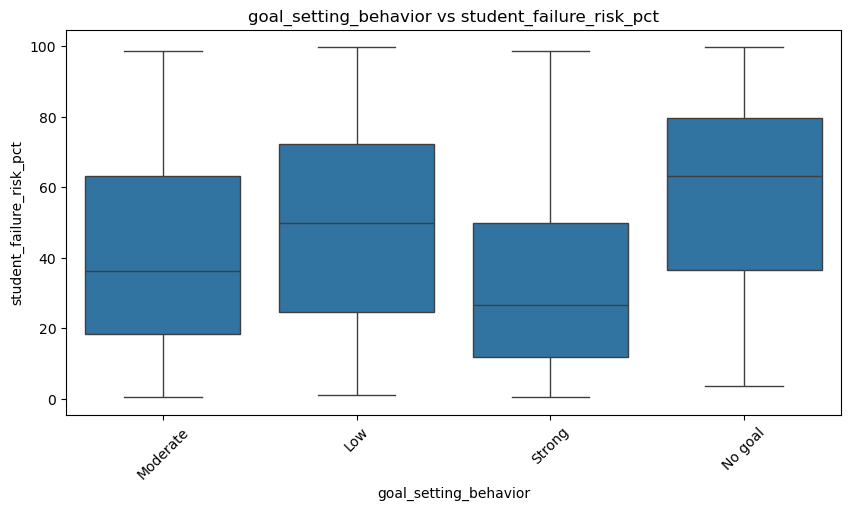

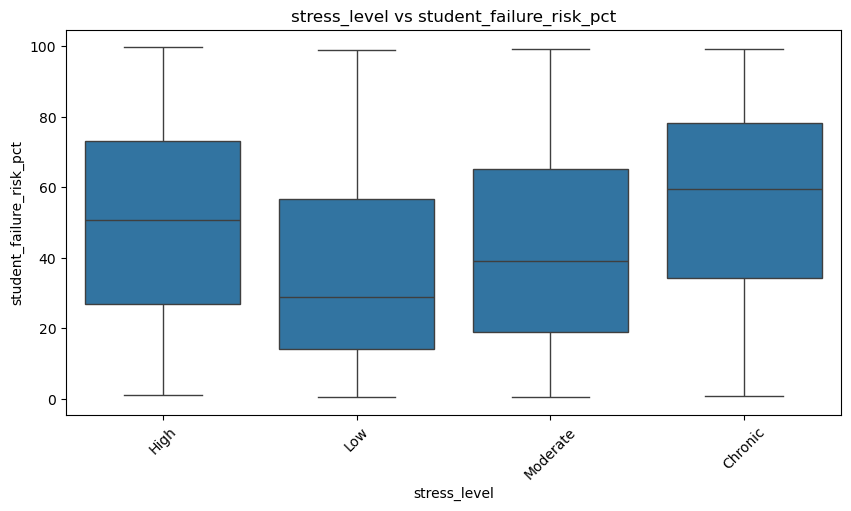

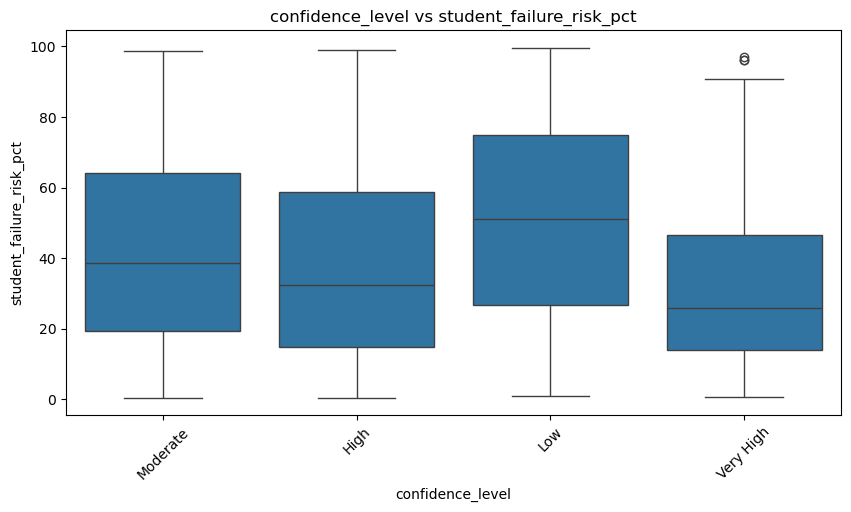

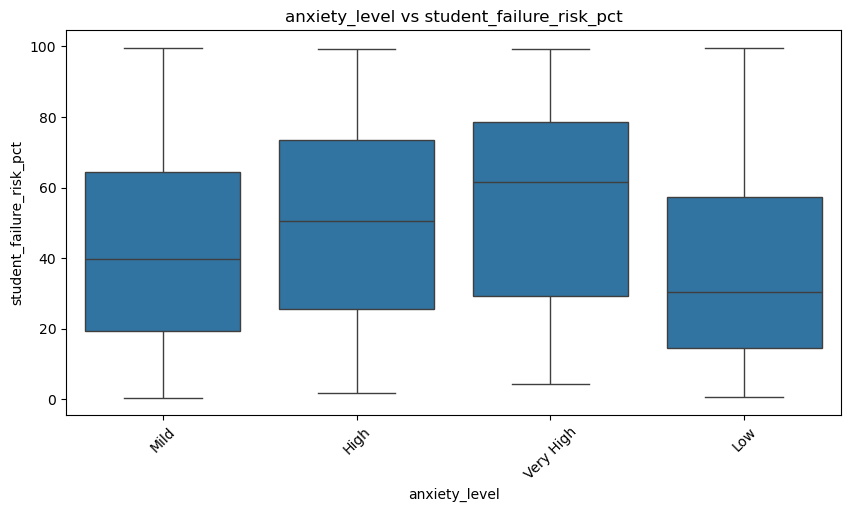

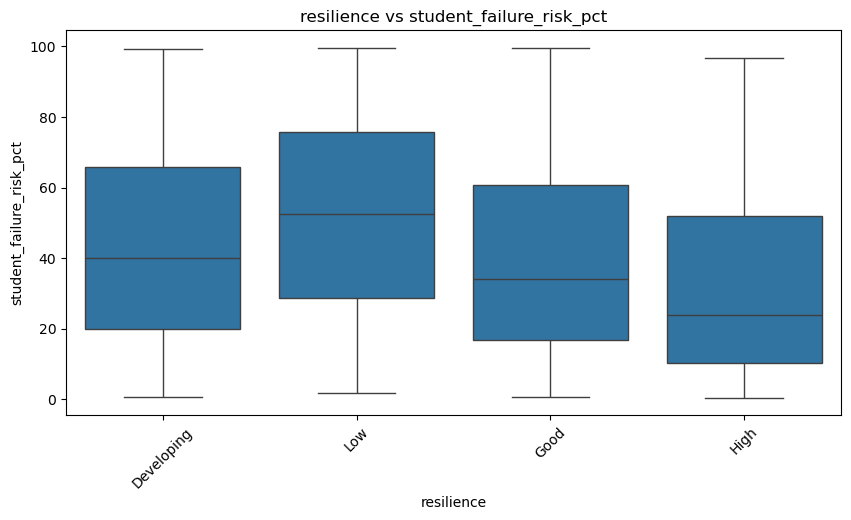

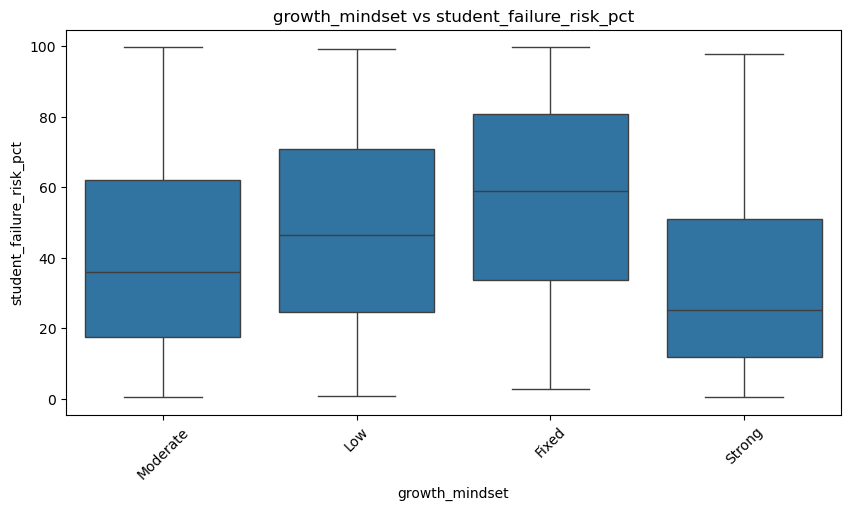

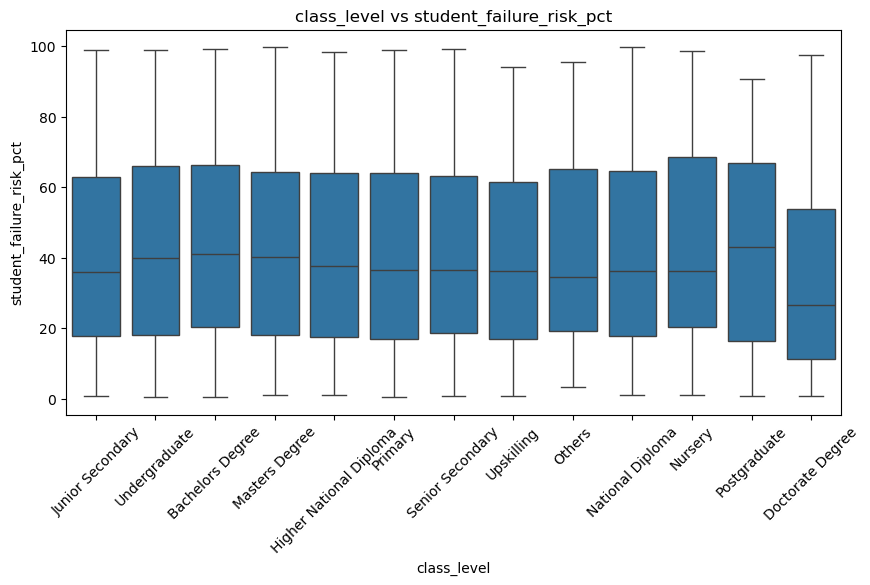

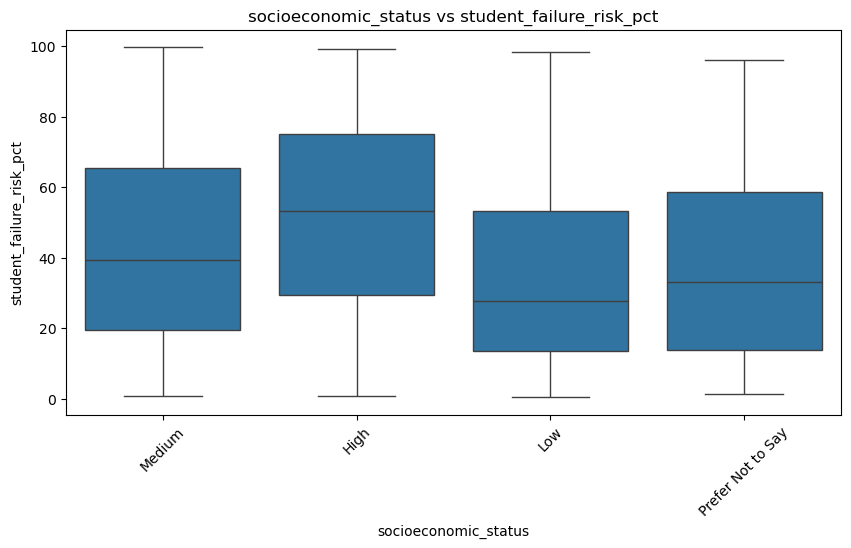

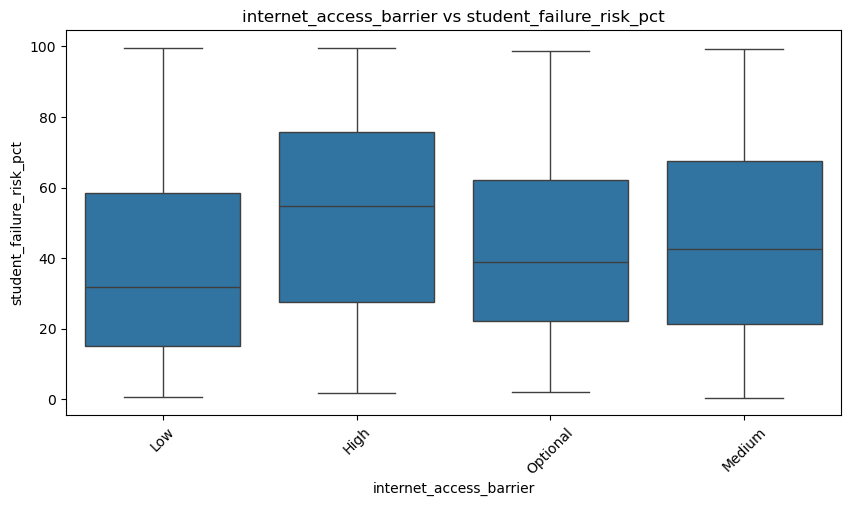

In [20]:
#Categorical Feature vs Target 
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col], y=df[target_col])
    plt.title(f"{col} vs {target_col}")
    plt.xticks(rotation=45)
    plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step  


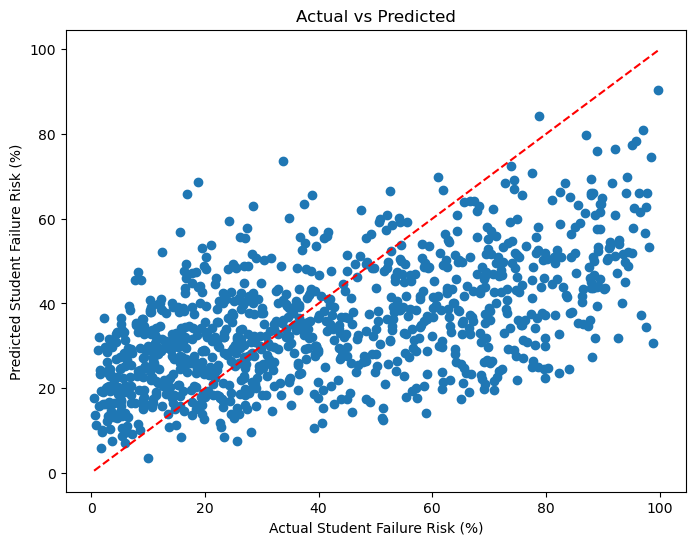

In [22]:
# Predict on test data
y_pred = model.predict({"categorical_sequence": X_test_seq, "numerical_input": X_test_num})

# Compare predictions vs true values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # y=x line
plt.xlabel("Actual Student Failure Risk (%)")
plt.ylabel("Predicted Student Failure Risk (%)")
plt.title("Actual vs Predicted")
plt.show()

In [33]:
def predict_student_failure(new_data):
    """
    Predict student_failure_risk_pct for a single student or batch.
    Automatically fills missing categorical/numerical columns with defaults.
    
    Parameters:
        new_data: dict (single student) or list of dicts (multiple students)
    
    Returns:
        NumPy array of predicted student_failure_risk_pct
    """
    import pandas as pd
    import numpy as np

    # Convert input to DataFrame
    if isinstance(new_data, dict):
        new_df = pd.DataFrame([new_data])
    else:
        new_df = pd.DataFrame(new_data)
    
    # Fill missing categorical columns with "Optional"
    for col in categorical_cols:
        if col not in new_df.columns:
            new_df[col] = "Optional"
    
    # Fill missing numerical columns with 0 (or you could choose mean values)
    for col in numerical_cols:
        if col not in new_df.columns:
            new_df[col] = 0.0

    # Ensure correct column order
    new_df = new_df[categorical_cols + numerical_cols]

    # Convert categorical columns to text sequence
    cat_text = new_df[categorical_cols].astype(str).agg(" ".join, axis=1)
    cat_seq_tensor = text_vectorizer(cat_text)
    cat_seq = cat_seq_tensor.numpy()  # convert to NumPy array for model input

    # Normalize numerical columns using the same scaler used in training
    num_data = scaler.transform(new_df[numerical_cols])

    # Make prediction
    prediction = model.predict({"categorical_sequence": cat_seq, "numerical_input": num_data})
    return prediction.flatten()

In [34]:
# Example student with some features
new_student = {
    "study_consistency": "Regular",
    "focus_quality": "High",
    "self_regulation": "Medium",
    "procrastination_level": "Low",
    "goal_setting_behavior": "Consistent",
    "stress_level": "Low",
    "confidence_level": "High",
    "anxiety_level": "Low",
    "resilience": "High",
    "growth_mindset": "Strong",
    "class_level": "Junior",
    "socioeconomic_status": "Medium",
    "internet_access_barrier": "No",
    "total_workload": 15,
    "avg_grade": 85.0,
    "class_avg": 80.0,
    "failed_quizzes": 1,
    "homework_accuracy": 90.0,
    "assignment_completion_rate": 95.0,
    "class_attendance_rate": 98.0,
    "avg_test_quiz_scores": 88.0,
    "class_avg_test_quiz_scores": 85.0,
    "age": 17
}

predicted_risk = predict_student_failure(new_student)
print(f"Predicted Student Failure Risk (%): {predicted_risk[0]:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Predicted Student Failure Risk (%): 32.16


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Predicted Student Failure Risk (%): 32.16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


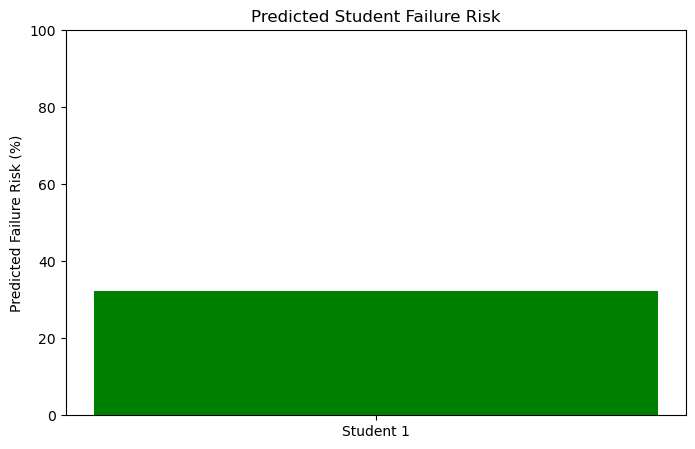

In [40]:
# Example student with all features filled
new_student_full = {
    # --- Categorical Features ---
    "study_consistency": "Regular",
    "focus_quality": "High",
    "self_regulation": "Medium",
    "procrastination_level": "Low",
    "goal_setting_behavior": "Consistent",
    "stress_level": "Low",
    "confidence_level": "High",
    "anxiety_level": "Low",
    "resilience": "High",
    "growth_mindset": "Strong",
    "class_level": "Junior",
    "socioeconomic_status": "Medium",
    "internet_access_barrier": "No",

    # --- Numerical Features ---
    "total_workload": 15,
    "avg_grade": 85.0,
    "class_avg": 80.0,
    "failed_quizzes": 1,
    "homework_accuracy": 90.0,
    "assignment_completion_rate": 95.0,
    "class_attendance_rate": 98.0,
    "avg_test_quiz_scores": 88.0,
    "class_avg_test_quiz_scores": 85.0,
    "age": 17
}

# Predict
predicted_risk_full = predict_student_failure(new_student_full)
print(f"Predicted Student Failure Risk (%): {predicted_risk_full[0]:.2f}")
# Predict
predicted_risks = predict_student_failure(new_student_full)

# Bar colors based on failure risk
colors = []
for risk in predicted_risks:
    if risk >= 70:
        colors.append("red")      # High risk
    elif risk >= 40:
        colors.append("orange")   # Medium risk
    else:
        colors.append("green")    # Low risk

# Plot
plt.figure(figsize=(8, 5))
plt.bar(range(len(predicted_risks)), predicted_risks, color=colors)
plt.xticks(range(len(predicted_risks)), [f"Student {i+1}" for i in range(len(predicted_risks))])
plt.ylabel("Predicted Failure Risk (%)")
plt.title("Predicted Student Failure Risk")
plt.ylim(0, 100)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


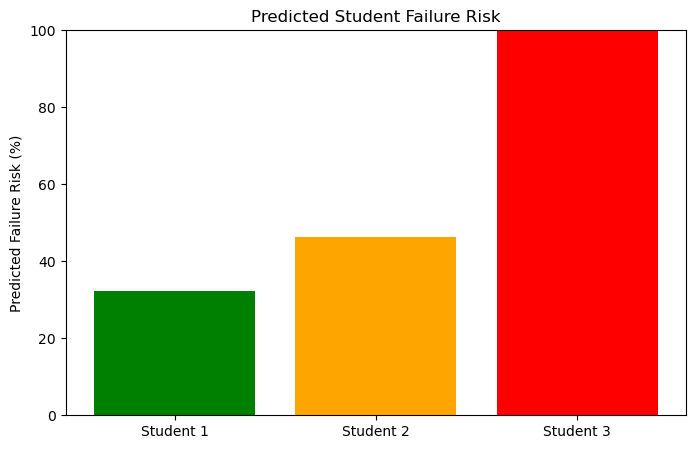

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Example batch of students
batch_students = [
    {
        "study_consistency": "Regular",
        "focus_quality": "High",
        "self_regulation": "Medium",
        "procrastination_level": "Low",
        "goal_setting_behavior": "Consistent",
        "stress_level": "Low",
        "confidence_level": "High",
        "anxiety_level": "Low",
        "resilience": "High",
        "growth_mindset": "Strong",
        "class_level": "Junior",
        "socioeconomic_status": "Medium",
        "internet_access_barrier": "No",
        "total_workload": 15,
        "avg_grade": 85.0,
        "class_avg": 80.0,
        "failed_quizzes": 1,
        "homework_accuracy": 90.0,
        "assignment_completion_rate": 95.0,
        "class_attendance_rate": 98.0,
        "avg_test_quiz_scores": 88.0,
        "class_avg_test_quiz_scores": 85.0,
        "age": 17
    },
    {
        "study_consistency": "Irregular",
        "focus_quality": "Low",
        "self_regulation": "Low",
        "procrastination_level": "High",
        "goal_setting_behavior": "Weak",
        "stress_level": "High",
        "confidence_level": "Low",
        "anxiety_level": "High",
        "resilience": "Low",
        "growth_mindset": "Low",
        "class_level": "Senior",
        "socioeconomic_status": "Low",
        "internet_access_barrier": "Yes",
        "total_workload": 25,
        "avg_grade": 50.0,
        "class_avg": 90.0,
        "failed_quizzes": 15,
        "homework_accuracy": 50.0,
        "assignment_completion_rate": 60.0,
        "class_attendance_rate": 70.0,
        "avg_test_quiz_scores": 52.0,
        "class_avg_test_quiz_scores": 60.0,
        "age": 18
    },
    {
        "study_consistency": "Moderate",
        "focus_quality": "Low",
        "self_regulation": "Low",
        "procrastination_level": "High",
        "goal_setting_behavior": "No goal",
        "stress_level": "High",
        "confidence_level": "Low",
        "anxiety_level": "High",
        "resilience": "Medium",
        "growth_mindset": "Low",
        "class_level": "Sophomore",
        "socioeconomic_status": "Low",
        "internet_access_barrier": "Yes",
        "total_workload": 18,
        "avg_grade": 70.0,
        "class_avg": 72.0,
        "failed_quizzes": 18,
        "homework_accuracy": 250,
        "assignment_completion_rate": 0.0,
        "class_attendance_rate": 5.0,
        "avg_test_quiz_scores": 8.0,
        "class_avg_test_quiz_scores": 70.0,
        "age": 17
    }
]

# Predict
predicted_risks = predict_student_failure(batch_students)

# Bar colors based on failure risk
colors = []
for risk in predicted_risks:
    if risk >= 70:
        colors.append("red")      # High risk
    elif risk >= 40:
        colors.append("orange")   # Medium risk
    else:
        colors.append("green")    # Low risk

# Plot
plt.figure(figsize=(8, 5))
plt.bar(range(len(predicted_risks)), predicted_risks, color=colors)
plt.xticks(range(len(predicted_risks)), [f"Student {i+1}" for i in range(len(predicted_risks))])
plt.ylabel("Predicted Failure Risk (%)")
plt.title("Predicted Student Failure Risk")
plt.ylim(0, 100)
plt.show()


In [41]:
# Save the main model in native Keras format
model.save("student_failure_model.keras")

In [42]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [44]:
import json

preprocessing_info = {
    "categorical_cols": categorical_cols,
    "numerical_cols": numerical_cols,
    "categorical_default": "Unknown",
    "numerical_default": 0.0
}

with open("failure_preprocessing_info.json", "w") as f:
    json.dump(preprocessing_info, f)

In [45]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import TextVectorization

# Wrap it
text_input = Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(text_input)
vectorizer_model = Model(text_input, x)

# Save the wrapper model
vectorizer_model.save("failure_text_vectorizer_model.keras")